In [1]:
from itertools import combinations
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform
from scipy.stats import kendalltau
from scipy.stats import pearsonr
from scipy.stats import skew, kurtosis
from scipy.stats import spearmanr

df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (23486, 11)

Column names:
['no', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']

First 5 rows:


,no,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses



Data types:
no                         int64
Clothing ID                int64
Age                        int64
Title                        str
Review Text                  str
Rating                     int64
Recommended IND            int64
Positive Feedback Count    int64
Division Name                str
Department Name              str
Class Name                   str
dtype: object

Missing values:
no                            0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64


In [2]:
correlation_columns = [
    "Age",
    "Rating",
    "Recommended IND",
    "Positive Feedback Count"
]

df_corr = df[correlation_columns].copy()

print("Selected columns:")
print(df_corr.columns.tolist())

print("\nDataset shape:")
print(df_corr.shape)

print("\nData types:")
print(df_corr.dtypes)

print("\nMissing values:")
print(df_corr.isnull().sum())

print("\nUnique values:")
print(df_corr.nunique())

print("\nDescriptive statistics:")
display(df_corr.describe().T)

Selected columns:
['Age', 'Rating', 'Recommended IND', 'Positive Feedback Count']

Dataset shape:
(23486, 4)

Data types:
Age                        int64
Rating                     int64
Recommended IND            int64
Positive Feedback Count    int64
dtype: object

Missing values:
Age                        0
Rating                     0
Recommended IND            0
Positive Feedback Count    0
dtype: int64

Unique values:
Age                        77
Rating                      5
Recommended IND             2
Positive Feedback Count    82
dtype: int64

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
Age,23486.0,43.198544,12.279544,18.0,34.0,41.0,52.0,99.0
Rating,23486.0,4.196032,1.110031,1.0,4.0,5.0,5.0,5.0
Recommended IND,23486.0,0.822362,0.382216,0.0,1.0,1.0,1.0,1.0
Positive Feedback Count,23486.0,2.535936,5.702202,0.0,0.0,1.0,3.0,122.0


In [3]:
distribution_results = []

for column in correlation_columns:
    distribution_results.append({
        "Variable": column,
        "Mean": df_corr[column].mean(),
        "Median": df_corr[column].median(),
        "Standard Deviation": df_corr[column].std(),
        "Skewness": skew(df_corr[column], nan_policy="omit"),
        "Kurtosis": kurtosis(df_corr[column], nan_policy="omit"),
        "Minimum": df_corr[column].min(),
        "Maximum": df_corr[column].max()
    })

distribution_summary = pd.DataFrame(distribution_results)

print("Distribution summary:")
display(distribution_summary.round(3))

Distribution summary:


,Variable,Mean,Median,Standard Deviation,Skewness,Kurtosis,Minimum,Maximum
0,Age,43.199,41.0,12.280,0.526,-0.112,18,99
1,Rating,4.196,5.0,1.110,-1.313,0.804,1,5
2,Recommended IND,0.822,1.0,0.382,-1.687,0.845,0,1
3,Positive Feedback Count,2.536,1.0,5.702,6.473,71.678,0,122


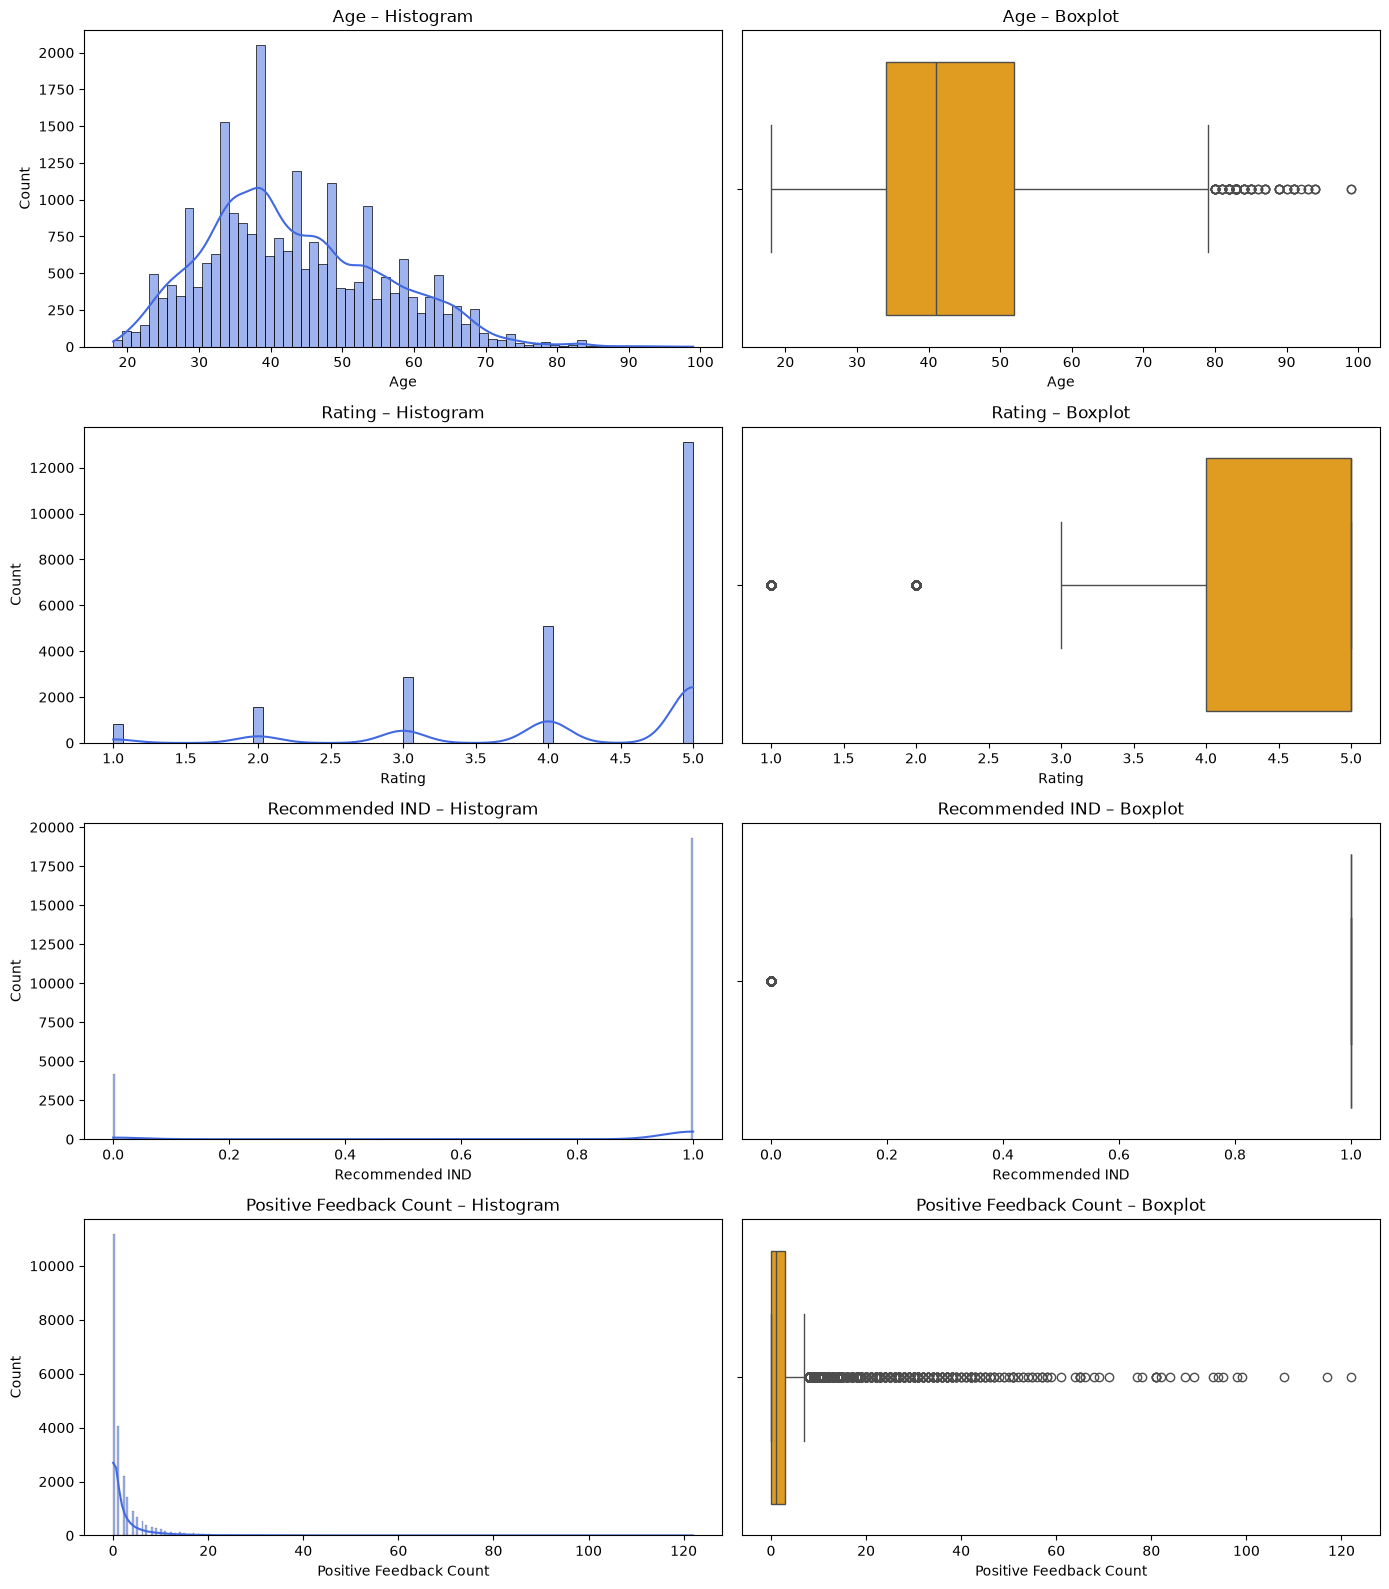

In [4]:
fig, axes = plt.subplots(
    nrows=len(correlation_columns),
    ncols=2,
    figsize=(14, 16)
)

for index, column in enumerate(correlation_columns):

    sns.histplot(
        data=df_corr,
        x=column,
        kde=True,
        ax=axes[index, 0],
        color="royalblue"
    )

    axes[index, 0].set_title(
        f"{column} – Histogram"
    )

    sns.boxplot(
        data=df_corr,
        x=column,
        ax=axes[index, 1],
        color="orange"
    )

    axes[index, 1].set_title(
        f"{column} – Boxplot"
    )

plt.tight_layout()
plt.show()

In [5]:
pearson_corr = df_corr.corr(method="pearson")

print("Pearson correlation matrix:")
display(pearson_corr.round(3))

Pearson correlation matrix:


,Age,Rating,Recommended IND,Positive Feedback Count
Age,1.000,0.027,0.031,0.043
Rating,0.027,1.000,0.792,-0.065
Recommended IND,0.031,0.792,1.000,-0.069
Positive Feedback Count,0.043,-0.065,-0.069,1.000


In [6]:
pearson_pvalues = pd.DataFrame(
    np.ones(
        (len(correlation_columns), len(correlation_columns))
    ),
    index=correlation_columns,
    columns=correlation_columns
)

for i, column_1 in enumerate(correlation_columns):
    for j, column_2 in enumerate(correlation_columns):

        if i != j:
            coefficient, p_value = pearsonr(
                df_corr[column_1],
                df_corr[column_2]
            )

            pearson_pvalues.loc[column_1, column_2] = p_value

print("Pearson p-value matrix:")
display(pearson_pvalues)

Pearson p-value matrix:


,Age,Rating,Recommended IND,Positive Feedback Count
Age,1.000000e+00,3.916600e-05,2.682754e-06,3.986206e-11
Rating,3.916600e-05,1.000000e+00,0.000000e+00,2.162492e-23
Recommended IND,2.682754e-06,0.000000e+00,1.000000e+00,3.198704e-26
Positive Feedback Count,3.986206e-11,2.162492e-23,3.198704e-26,1.000000e+00


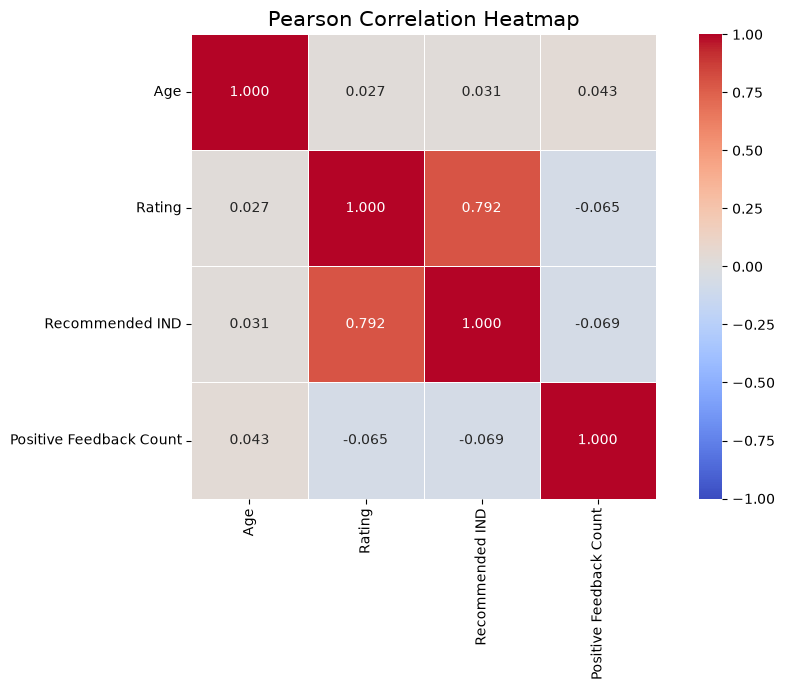

In [7]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    square=True
)

plt.title(
    "Pearson Correlation Heatmap",
    fontsize=15
)

plt.tight_layout()
plt.show()

In [8]:
spearman_corr = df_corr.corr(method="spearman")

print("Spearman correlation matrix:")
display(spearman_corr.round(3))

Spearman correlation matrix:


,Age,Rating,Recommended IND,Positive Feedback Count
Age,1.000,0.031,0.031,0.076
Rating,0.031,1.000,0.694,-0.068
Recommended IND,0.031,0.694,1.000,-0.081
Positive Feedback Count,0.076,-0.068,-0.081,1.000


In [9]:
spearman_pvalues = pd.DataFrame(
    np.ones(
        (len(correlation_columns), len(correlation_columns))
    ),
    index=correlation_columns,
    columns=correlation_columns
)

for i, column_1 in enumerate(correlation_columns):
    for j, column_2 in enumerate(correlation_columns):

        if i != j:
            coefficient, p_value = spearmanr(
                df_corr[column_1],
                df_corr[column_2],
                nan_policy="omit"
            )

            spearman_pvalues.loc[
                column_1,
                column_2
            ] = p_value

print("Spearman p-value matrix:")
display(spearman_pvalues)

Spearman p-value matrix:


,Age,Rating,Recommended IND,Positive Feedback Count
Age,1.000000e+00,1.895027e-06,1.968519e-06,4.158458e-31
Rating,1.895027e-06,1.000000e+00,0.000000e+00,1.034571e-25
Recommended IND,1.968519e-06,0.000000e+00,1.000000e+00,2.244635e-35
Positive Feedback Count,4.158458e-31,1.034571e-25,2.244635e-35,1.000000e+00


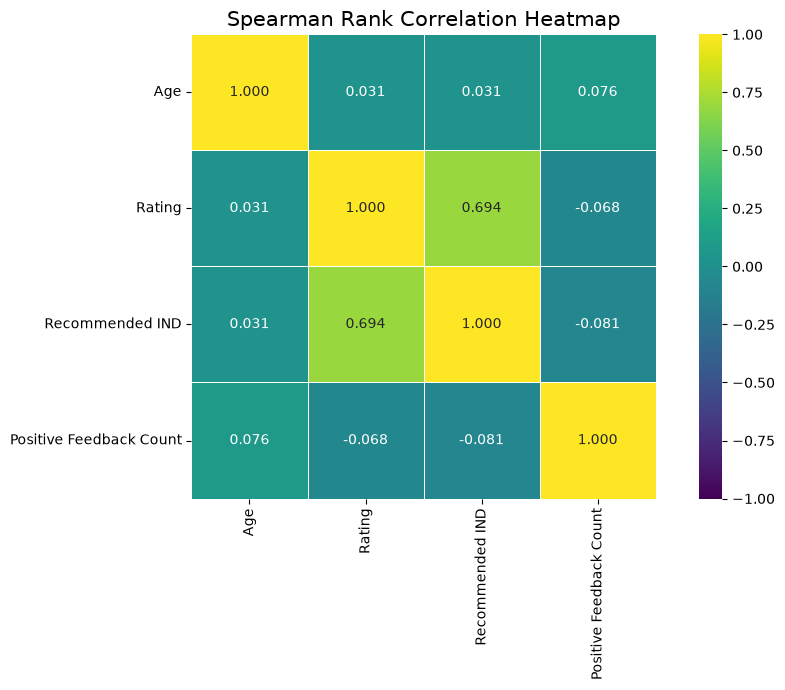

In [10]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    square=True
)

plt.title(
    "Spearman Rank Correlation Heatmap",
    fontsize=15
)

plt.tight_layout()
plt.show()

In [11]:
kendall_corr = df_corr.corr(method="kendall")

print("Kendall correlation matrix:")
display(kendall_corr.round(3))

Kendall correlation matrix:


,Age,Rating,Recommended IND,Positive Feedback Count
Age,1.000,0.024,0.026,0.056
Rating,0.024,1.000,0.648,-0.058
Recommended IND,0.026,0.648,1.000,-0.073
Positive Feedback Count,0.056,-0.058,-0.073,1.000


In [12]:
kendall_pvalues = pd.DataFrame(
    np.ones(
        (len(correlation_columns), len(correlation_columns))
    ),
    index=correlation_columns,
    columns=correlation_columns
)

for i, column_1 in enumerate(correlation_columns):
    for j, column_2 in enumerate(correlation_columns):

        if i != j:
            coefficient, p_value = kendalltau(
                df_corr[column_1],
                df_corr[column_2],
                nan_policy="omit"
            )

            kendall_pvalues.loc[
                column_1,
                column_2
            ] = p_value

print("Kendall p-value matrix:")
display(kendall_pvalues)

Kendall p-value matrix:


,Age,Rating,Recommended IND,Positive Feedback Count
Age,1.000000e+00,1.784147e-06,1.978227e-06,7.342775e-31
Rating,1.784147e-06,1.000000e+00,0.000000e+00,1.234957e-25
Recommended IND,1.978227e-06,0.000000e+00,1.000000e+00,2.878744e-35
Positive Feedback Count,7.342775e-31,1.234957e-25,2.878744e-35,1.000000e+00


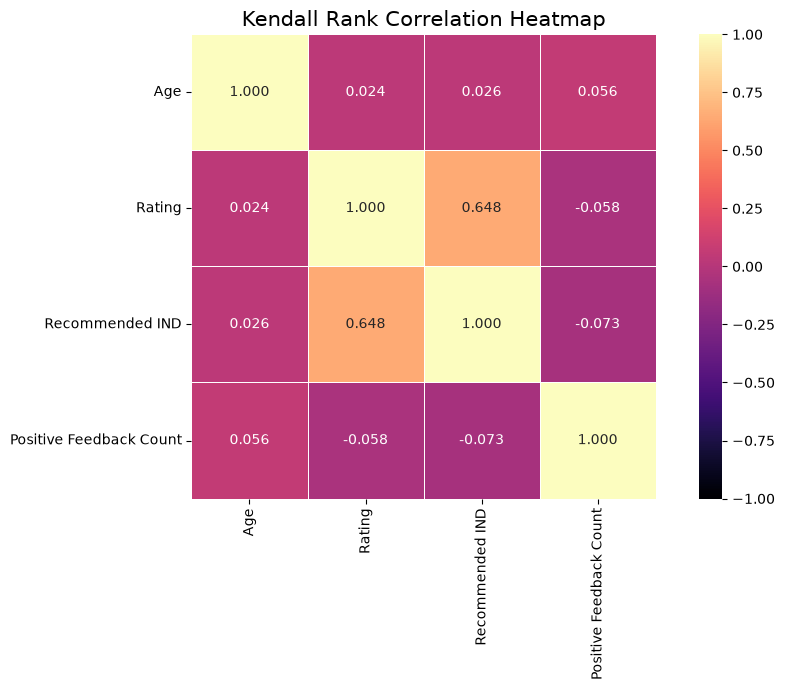

In [13]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    kendall_corr,
    annot=True,
    fmt=".3f",
    cmap="magma",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    square=True
)

plt.title(
    "Kendall Rank Correlation Heatmap",
    fontsize=15
)

plt.tight_layout()
plt.show()

In [14]:
comparison_records = []

for variable_1, variable_2 in combinations(
    correlation_columns,
    2
):
    pearson_value = pearson_corr.loc[
        variable_1, variable_2
    ]

    spearman_value = spearman_corr.loc[
        variable_1, variable_2
    ]

    kendall_value = kendall_corr.loc[
        variable_1, variable_2
    ]

    comparison_records.append({
        "Variable 1": variable_1,
        "Variable 2": variable_2,

        "Pearson": pearson_value,
        "Pearson p-value": pearson_pvalues.loc[
            variable_1, variable_2
        ],

        "Spearman": spearman_value,
        "Spearman p-value": spearman_pvalues.loc[
            variable_1, variable_2
        ],

        "Kendall": kendall_value,
        "Kendall p-value": kendall_pvalues.loc[
            variable_1, variable_2
        ],

        "Direction Consistent": (
            np.sign(pearson_value)
            == np.sign(spearman_value)
            == np.sign(kendall_value)
        )
    })

correlation_comparison = pd.DataFrame(
    comparison_records
)

correlation_comparison["Absolute Pearson"] = (
    correlation_comparison["Pearson"].abs()
)

correlation_comparison = (
    correlation_comparison
    .sort_values(
        by="Absolute Pearson",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Correlation metrics comparison:")
display(
    correlation_comparison.round(4)
)

Correlation metrics comparison:


,Variable 1,Variable 2,Pearson,Pearson p-value,Spearman,Spearman p-value,Kendall,Kendall p-value,Direction Consistent,Absolute Pearson
0,Rating,Recommended IND,0.7923,0.0,0.6935,0.0,0.6484,0.0,True,0.7923
1,Recommended IND,Positive Feedback Count,-0.0690,0.0,-0.0809,0.0,-0.0729,0.0,True,0.0690
2,Rating,Positive Feedback Count,-0.0650,0.0,-0.0683,0.0,-0.0575,0.0,True,0.0650
3,Age,Positive Feedback Count,0.0431,0.0,0.0756,0.0,0.0561,0.0,True,0.0431
4,Age,Recommended IND,0.0306,0.0,0.0310,0.0,0.0256,0.0,True,0.0306
5,Age,Rating,0.0268,0.0,0.0311,0.0,0.0241,0.0,True,0.0268


In [15]:
def classify_correlation(value):
    absolute_value = abs(value)

    if absolute_value >= 0.70:
        return "Strong"
    elif absolute_value >= 0.40:
        return "Moderate"
    elif absolute_value >= 0.20:
        return "Weak"
    else:
        return "Very Weak"

correlation_comparison["Pearson Strength"] = (
    correlation_comparison["Pearson"]
    .apply(classify_correlation)
)

correlation_comparison["Spearman Strength"] = (
    correlation_comparison["Spearman"]
    .apply(classify_correlation)
)

correlation_comparison["Kendall Strength"] = (
    correlation_comparison["Kendall"]
    .apply(classify_correlation)
)

display(
    correlation_comparison.round(4)
)

,Variable 1,Variable 2,Pearson,Pearson p-value,Spearman,Spearman p-value,Kendall,Kendall p-value,Direction Consistent,Absolute Pearson,Pearson Strength,Spearman Strength,Kendall Strength
0,Rating,Recommended IND,0.7923,0.0,0.6935,0.0,0.6484,0.0,True,0.7923,Strong,Moderate,Moderate
1,Recommended IND,Positive Feedback Count,-0.0690,0.0,-0.0809,0.0,-0.0729,0.0,True,0.0690,Very Weak,Very Weak,Very Weak
2,Rating,Positive Feedback Count,-0.0650,0.0,-0.0683,0.0,-0.0575,0.0,True,0.0650,Very Weak,Very Weak,Very Weak
3,Age,Positive Feedback Count,0.0431,0.0,0.0756,0.0,0.0561,0.0,True,0.0431,Very Weak,Very Weak,Very Weak
4,Age,Recommended IND,0.0306,0.0,0.0310,0.0,0.0256,0.0,True,0.0306,Very Weak,Very Weak,Very Weak
5,Age,Rating,0.0268,0.0,0.0311,0.0,0.0241,0.0,True,0.0268,Very Weak,Very Weak,Very Weak


In [16]:
alpha = 0.05
minimum_correlation = 0.20

In [17]:
def filter_significant_correlations(
    correlation_matrix,
    pvalue_matrix,
    method_name,
    alpha=0.05,
    minimum_correlation=0.20
):
    significant_records = []

    for variable_1, variable_2 in combinations(
        correlation_matrix.columns,
        2
    ):
        coefficient = correlation_matrix.loc[
            variable_1, variable_2
        ]

        p_value = pvalue_matrix.loc[
            variable_1, variable_2
        ]

        if (
            p_value < alpha
            and abs(coefficient) >= minimum_correlation
        ):
            significant_records.append({
                "Method": method_name,
                "Variable 1": variable_1,
                "Variable 2": variable_2,
                "Correlation": coefficient,
                "Absolute Correlation": abs(coefficient),
                "p-value": p_value,
                "Direction": (
                    "Positive"
                    if coefficient > 0
                    else "Negative"
                ),
                "Strength": classify_correlation(
                    coefficient
                )
            })

    return pd.DataFrame(significant_records)

In [18]:
significant_pearson = filter_significant_correlations(
    pearson_corr,
    pearson_pvalues,
    method_name="Pearson",
    alpha=alpha,
    minimum_correlation=minimum_correlation
)

significant_spearman = filter_significant_correlations(
    spearman_corr,
    spearman_pvalues,
    method_name="Spearman",
    alpha=alpha,
    minimum_correlation=minimum_correlation
)

significant_kendall = filter_significant_correlations(
    kendall_corr,
    kendall_pvalues,
    method_name="Kendall",
    alpha=alpha,
    minimum_correlation=minimum_correlation
)

significant_correlations = pd.concat(
    [
        significant_pearson,
        significant_spearman,
        significant_kendall
    ],
    ignore_index=True
)

if significant_correlations.empty:
    print("Given thresholds par koi correlation nahi mila.")

else:
    significant_correlations = (
        significant_correlations
        .sort_values(
            by="Absolute Correlation",
            ascending=False
        )
        .reset_index(drop=True)
    )

    print("Dynamically filtered significant correlations:")
    display(
        significant_correlations.round(4)
    )

Dynamically filtered significant correlations:


,Method,Variable 1,Variable 2,Correlation,Absolute Correlation,p-value,Direction,Strength
0,Pearson,Rating,Recommended IND,0.7923,0.7923,0.0,Positive,Strong
1,Spearman,Rating,Recommended IND,0.6935,0.6935,0.0,Positive,Moderate
2,Kendall,Rating,Recommended IND,0.6484,0.6484,0.0,Positive,Moderate


In [26]:
def create_clustered_heatmap(
    correlation_matrix,
    method_name,
    color_map="coolwarm"
):

    distance_matrix = (
        1 - correlation_matrix.abs()
    ).clip(lower=0, upper=1)

    distance_array = distance_matrix.to_numpy(
        copy=True
    )

    np.fill_diagonal(
        distance_array,
        0
    )

    condensed_distance = squareform(
        distance_array,
        checks=False
    )

    linkage_matrix = linkage(
        condensed_distance,
        method="average"
    )

    cluster_grid = sns.clustermap(
        correlation_matrix,
        row_linkage=linkage_matrix,
        col_linkage=linkage_matrix,
        cmap=color_map,
        vmin=-1,
        vmax=1,
        center=0,
        annot=True,
        fmt=".3f",
        linewidths=0.5,
        figsize=(10, 9),
        dendrogram_ratio=(0.15, 0.15),
        cbar_kws={
            "label": "Correlation coefficient"
        }
    )

    cluster_grid.fig.suptitle(
        f"{method_name} Correlation with Hierarchical Clustering",
        fontsize=15,
        y=1.02
    )

    plt.show()

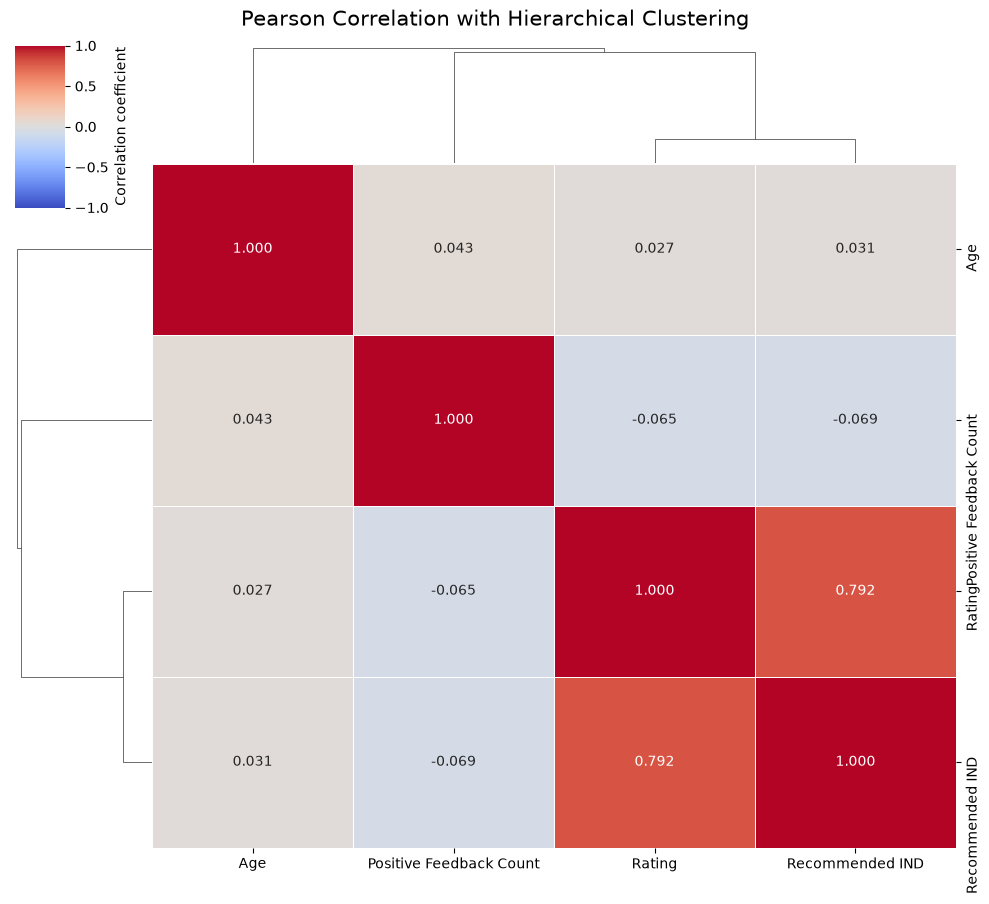

In [27]:
create_clustered_heatmap(
    pearson_corr,
    method_name="Pearson",
    color_map="coolwarm"
)

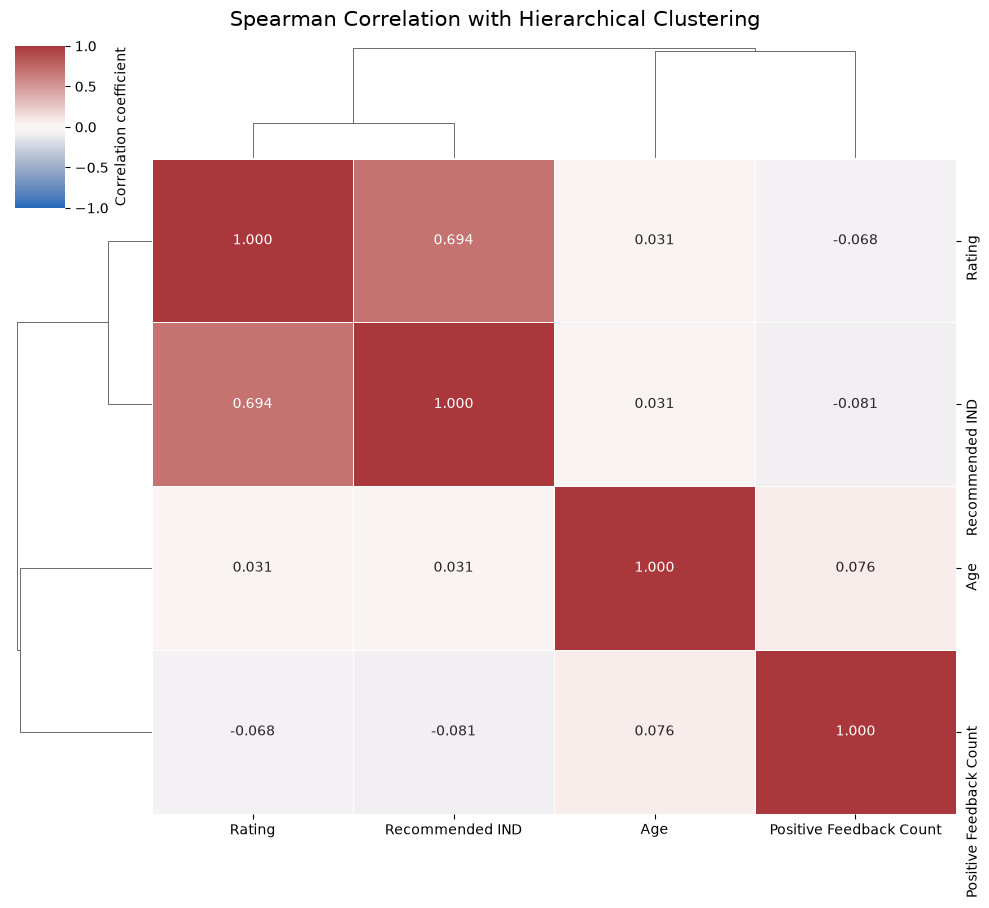

In [28]:
create_clustered_heatmap(
    spearman_corr,
    method_name="Spearman",
    color_map="vlag"
)

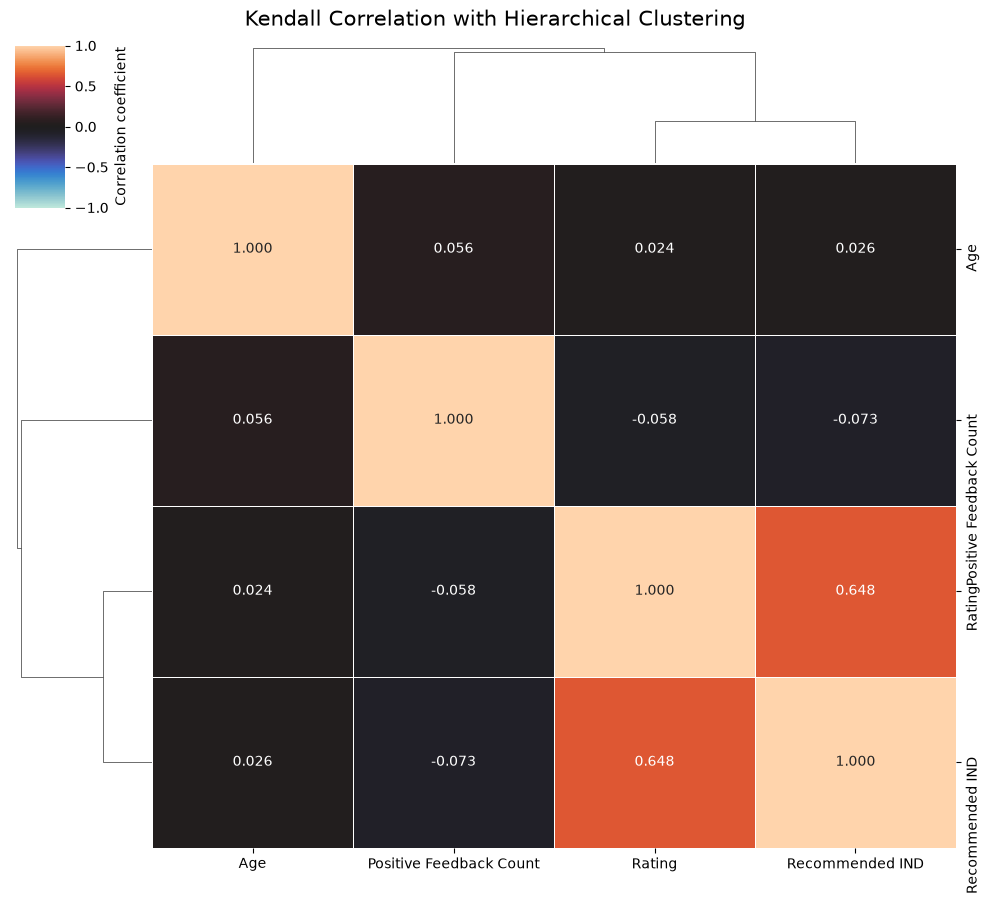

In [29]:
create_clustered_heatmap(
    kendall_corr,
    method_name="Kendall",
    color_map="icefire"
)

In [31]:
correlation_comparison["All Metrics Significant"] = (
    (correlation_comparison["Pearson p-value"] < alpha)
    & (correlation_comparison["Spearman p-value"] < alpha)
    & (correlation_comparison["Kendall p-value"] < alpha)
)

correlation_comparison["All Metrics Practical"] = (
    (correlation_comparison["Pearson"].abs() >= minimum_correlation)
    & (correlation_comparison["Spearman"].abs() >= minimum_correlation)
    & (correlation_comparison["Kendall"].abs() >= minimum_correlation)
)

final_relationships = correlation_comparison[
    correlation_comparison["All Metrics Significant"]
    & correlation_comparison["All Metrics Practical"]
    & correlation_comparison["Direction Consistent"]
].copy()

print("Final reliable relationships:")

if final_relationships.empty:
    print("Selected thresholds par koi reliable relationship nahi mila.")
else:
    display(final_relationships.round(4))

Final reliable relationships:


,Variable 1,Variable 2,Pearson,Pearson p-value,Spearman,Spearman p-value,Kendall,Kendall p-value,Direction Consistent,Absolute Pearson,Pearson Strength,Spearman Strength,Kendall Strength,All Metrics Significant,All Metrics Practical
0,Rating,Recommended IND,0.7923,0.0,0.6935,0.0,0.6484,0.0,True,0.7923,Strong,Moderate,Moderate,True,True


In [32]:
output_folder = "correlation_analysis_results"

os.makedirs(
    output_folder,
    exist_ok=True
)

pearson_corr.to_csv(
    os.path.join(
        output_folder,
        "pearson_correlation_matrix.csv"
    )
)

spearman_corr.to_csv(
    os.path.join(
        output_folder,
        "spearman_correlation_matrix.csv"
    )
)

kendall_corr.to_csv(
    os.path.join(
        output_folder,
        "kendall_correlation_matrix.csv"
    )
)

pearson_pvalues.to_csv(
    os.path.join(
        output_folder,
        "pearson_pvalues.csv"
    )
)

spearman_pvalues.to_csv(
    os.path.join(
        output_folder,
        "spearman_pvalues.csv"
    )
)

kendall_pvalues.to_csv(
    os.path.join(
        output_folder,
        "kendall_pvalues.csv"
    )
)

correlation_comparison.to_csv(
    os.path.join(
        output_folder,
        "correlation_metrics_comparison.csv"
    ),
    index=False
)

significant_correlations.to_csv(
    os.path.join(
        output_folder,
        "significant_correlations.csv"
    ),
    index=False
)

final_relationships.to_csv(
    os.path.join(
        output_folder,
        "final_reliable_relationships.csv"
    ),
    index=False
)

print("All result files successfully saved.")
print("Output folder:", output_folder)

All result files successfully saved.
Output folder: correlation_analysis_results
